In [2]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler,RobustScaler ##importing
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier ## lazypredict for which model best for my data, we will see it after preprocessing and data cleaning.
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
import seaborn as sns

In [3]:
df = pd.read_csv("healthcare_dataset.csv") ##reading dataset

In [4]:
df.head(50) ##checking first 50 rows

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.87,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.46,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.22,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.63,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [5]:
df.info() ## checking columns, types, and nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.isna().sum() ## for my safety, im checking with isna().sum() command

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

<Axes: >

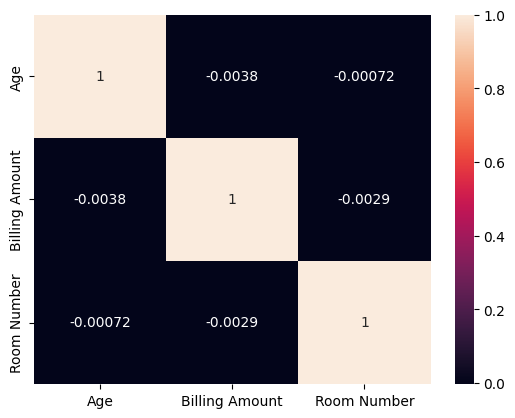

In [7]:
sns.heatmap(df.corr(numeric_only = True), annot = True) ## im checking correlation map and i saw there is nothing for record

In [8]:
df['Name'] = df['Name'].str.strip().str.title() ## the names were messy strings, and we fix this with cell.

In [9]:
df.drop(columns = ['Doctor','Billing Amount','Room Number','Name','Hospital','Date of Admission','Discharge Date'], inplace = True) ## the columns are not important for my model.

In [10]:
df[["Blood Type","Medical Condition","Gender","Insurance Provider","Medication","Admission Type"]].nunique() ## look for which columns i preprocess with onehotencoder, and we see we cant preprocess doctor and hospital columns with onehotencoder.

Blood Type            8
Medical Condition     6
Gender                2
Insurance Provider    5
Medication            5
Admission Type        3
dtype: int64

In [11]:
X = df.drop(columns = "Test Results")
y = df["Test Results"]                   # i configured the output for test results column.

In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42       ## we configure our test and train data for machine learning
)

In [13]:
num = df.select_dtypes('number').columns
cat = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']          ## selecting my number and categorical columns for pipeline preprocessing

In [14]:
num ## there is no problem

Index(['Age'], dtype='object')

In [15]:
cat ## im gonne preprocess it :D

['Gender',
 'Blood Type',
 'Medical Condition',
 'Insurance Provider',
 'Admission Type',
 'Medication']

In [16]:
cat_pip = Pipeline([
    ("one", OneHotEncoder(handle_unknown = 'ignore'))
])      ##

In [17]:
preprocess = ColumnTransformer([
   # ("num", num_pip, num) if we should numeric preprocessing we will do it too
    ("cat", cat_pip, cat)
])
### its for pipeline just apply for cat columns

In [18]:
model = Pipeline([
    ("pre",preprocess),
    ("randomforest",RandomForestClassifier(n_estimators = 200,random_state = 42))
]) # im gonne use randomforest for that

In [ ]:
model.fit(X_train,y_train) # fitting the model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('randomforest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [ ]:
score = model.score(X_test, y_test)
print(f"Model's Accurate: {score}") ## checking accurate

Model's Accurate: 0.3618018018018018


In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred)) ## it is sintetic data, thats why %36 accuracy , and if u check urself u gonna see all models accuracy around 35-40 for this data

              precision    recall  f1-score   support

    Abnormal       0.36      0.37      0.37      3754
Inconclusive       0.36      0.36      0.36      3617
      Normal       0.36      0.35      0.36      3729

    accuracy                           0.36     11100
   macro avg       0.36      0.36      0.36     11100
weighted avg       0.36      0.36      0.36     11100

